<a href="https://colab.research.google.com/github/mitparekh8263/CV-2026-H11/blob/main/Practical_07/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage.feature import graycomatrix, graycoprops
from skimage import data

Loading the Image and Extracting Patches

In [27]:
patch_size = 21

image = data.camera()

grass_locations = [(280, 454), (342, 223), (444, 192), (455, 455)]
sky_locations = [(38, 34), (139, 28), (37, 437), (145, 379)]

grass_patches = []
for loc in grass_locations:
    y = loc[0]
    x = loc[1]
    patch = image[y : y+patch_size, x : x+patch_size]
    grass_patches.append(patch)

sky_patches = []
for loc in sky_locations:
    y = loc[0]
    x = loc[1]
    patch = image[y : y+patch_size, x : x+patch_size]
    sky_patches.append(patch)

print(f"Total Grass Patches Extracted: {len(grass_patches)} | Single Patch Shape: {grass_patches[0].shape}")
print(f"Total Sky Patches Extracted:   {len(sky_patches)} | Single Patch Shape: {sky_patches[0].shape}")

Total Grass Patches Extracted: 4 | Single Patch Shape: (21, 21)
Total Sky Patches Extracted:   4 | Single Patch Shape: (21, 21)


Calculating GLCM and Extracting Features

In [28]:
grass_dissimilarity = []
grass_correlation = []
grass_contrast = []
grass_homogeneity = []
grass_energy = []
grass_asm = []

sky_dissimilarity = []
sky_correlation = []
sky_contrast = []
sky_homogeneity = []
sky_energy = []
sky_asm = []

for patch in grass_patches:
    glcm = graycomatrix(patch, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)

    grass_dissimilarity.append(graycoprops(glcm, 'dissimilarity')[0, 0])
    grass_correlation.append(graycoprops(glcm, 'correlation')[0, 0])
    grass_contrast.append(graycoprops(glcm, 'contrast')[0, 0])
    grass_homogeneity.append(graycoprops(glcm, 'homogeneity')[0, 0])
    grass_energy.append(graycoprops(glcm, 'energy')[0, 0])
    grass_asm.append(graycoprops(glcm, 'ASM')[0, 0])

for patch in sky_patches:
    glcm = graycomatrix(patch, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)

    sky_dissimilarity.append(graycoprops(glcm, 'dissimilarity')[0, 0])
    sky_correlation.append(graycoprops(glcm, 'correlation')[0, 0])
    sky_contrast.append(graycoprops(glcm, 'contrast')[0, 0])
    sky_homogeneity.append(graycoprops(glcm, 'homogeneity')[0, 0])
    sky_energy.append(graycoprops(glcm, 'energy')[0, 0])
    sky_asm.append(graycoprops(glcm, 'ASM')[0, 0])

Printing Extracted Features

In [29]:
print("| Patch Type | Dissimilarity | Correlation | Contrast | Homogeneity | Energy | ASM   |\n")

for i in range(len(grass_patches)):
    print(f"| Grass {i+1}    | {grass_dissimilarity[i]:13.3f} | {grass_correlation[i]:11.3f} | {grass_contrast[i]:8.3f} | {grass_homogeneity[i]:11.3f} | {grass_energy[i]:6.3f} | {grass_asm[i]:5.3f} |")

print("\n")

for i in range(len(sky_patches)):
    print(f"| Sky {i+1}      | {sky_dissimilarity[i]:13.3f} | {sky_correlation[i]:11.3f} | {sky_contrast[i]:8.3f} | {sky_homogeneity[i]:11.3f} | {sky_energy[i]:6.3f} | {sky_asm[i]:5.3f} |")


| Patch Type | Dissimilarity | Correlation | Contrast | Homogeneity | Energy | ASM   |

| Grass 1    |         6.045 |       0.185 |   57.729 |       0.156 |  0.062 | 0.004 |
| Grass 2    |        11.973 |       0.098 |  217.420 |       0.069 |  0.048 | 0.002 |
| Grass 3    |        18.795 |       0.012 |  564.723 |       0.051 |  0.043 | 0.002 |
| Grass 4    |        18.801 |       0.032 |  554.640 |       0.044 |  0.043 | 0.002 |


| Sky 1      |         0.467 |       0.650 |    0.545 |       0.774 |  0.407 | 0.166 |
| Sky 2      |         0.574 |       0.730 |    0.693 |       0.725 |  0.307 | 0.094 |
| Sky 3      |         0.521 |       0.767 |    0.586 |       0.746 |  0.320 | 0.102 |
| Sky 4      |         0.539 |       0.515 |    0.646 |       0.741 |  0.406 | 0.165 |


Visualizing the Original Image and Patches

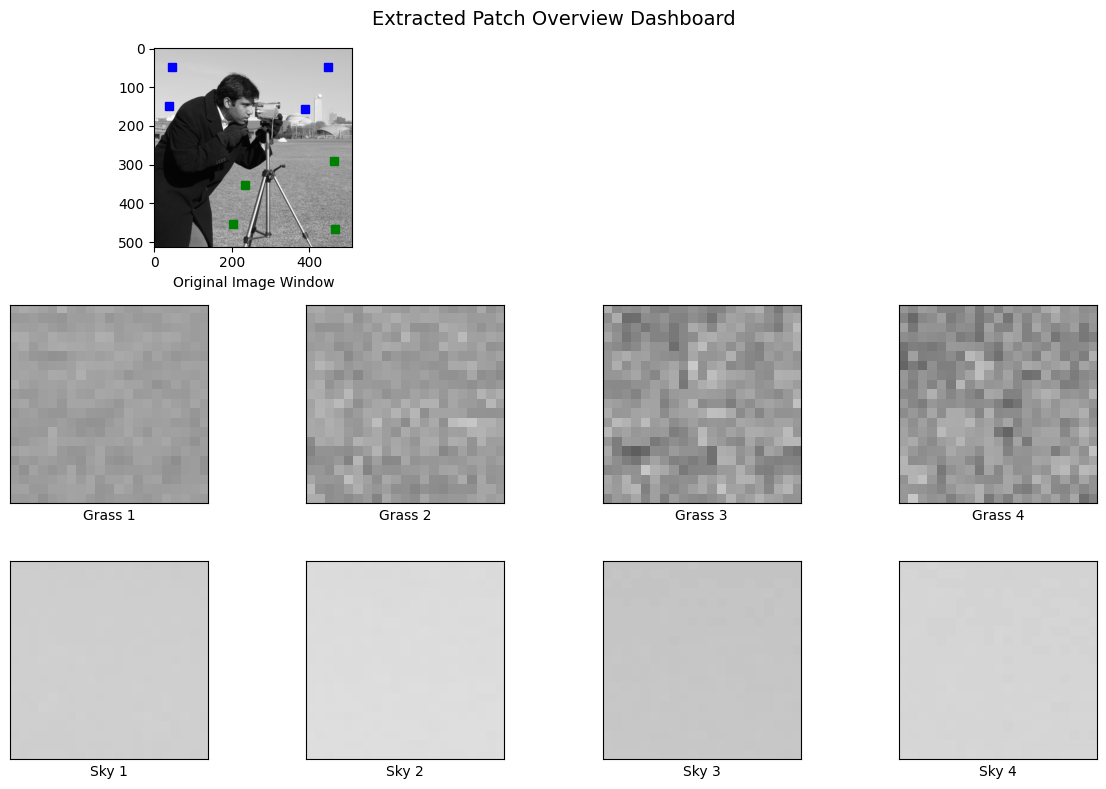

In [30]:
fig = plt.figure(figsize=(12, 8))

ax_main = fig.add_subplot(3, 2, 1)
ax_main.imshow(image, cmap=plt.cm.gray, vmin=0, vmax=255)

for loc in grass_locations:
    y = loc[0]
    x = loc[1]
    ax_main.plot(x + patch_size / 2, y + patch_size / 2, 'gs')

for loc in sky_locations:
    y = loc[0]
    x = loc[1]
    ax_main.plot(x + patch_size / 2, y + patch_size / 2, 'bs')

ax_main.set_xlabel('Original Image Window')
ax_main.axis('image')

for i in range(len(grass_patches)):
    # Position calculation: bottom slots row index 2
    ax_patch = fig.add_subplot(3, len(grass_patches), len(grass_patches) * 1 + i + 1)
    ax_patch.imshow(grass_patches[i], cmap=plt.cm.gray, vmin=0, vmax=255)
    ax_patch.set_xlabel(f"Grass {i + 1}")
    ax_patch.set_xticks([])
    ax_patch.set_yticks([])

for i in range(len(sky_patches)):
    # Position calculation: bottom slots row index 3
    ax_patch = fig.add_subplot(3, len(sky_patches), len(sky_patches) * 2 + i + 1)
    ax_patch.imshow(sky_patches[i], cmap=plt.cm.gray, vmin=0, vmax=255)
    ax_patch.set_xlabel(f"Sky {i + 1}")
    ax_patch.set_xticks([])
    ax_patch.set_yticks([])

plt.suptitle('Extracted Patch Overview Dashboard', fontsize=14)
plt.tight_layout()
plt.show()

3D Feature Space Scatter Plot

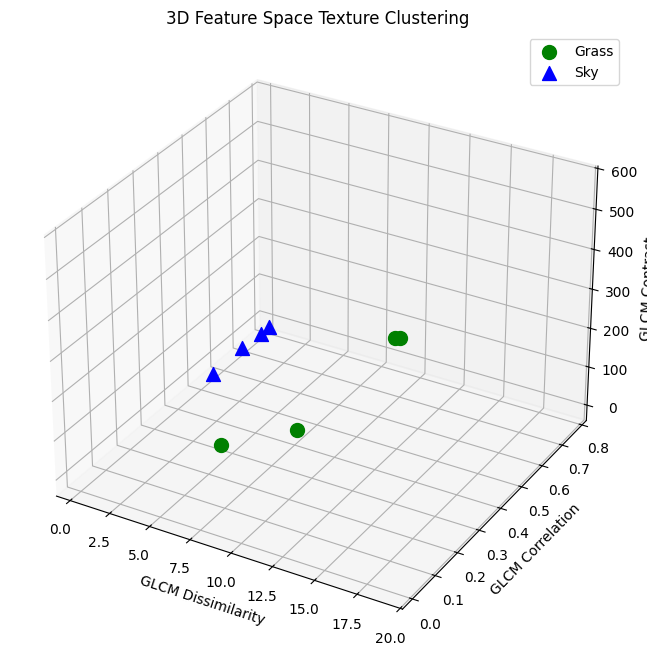

In [31]:
fig_3d = plt.figure(figsize=(10, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d')

for i in range(len(grass_patches)):
    # Isolate individual coordinates
    x_val = grass_dissimilarity[i]
    y_val = grass_correlation[i]
    z_val = grass_contrast[i]

    # Assign a label only to the first point to keep the legend neat
    if i == 0:
        point_label = 'Grass'
    else:
        point_label = ""

    ax_3d.scatter(x_val, y_val, z_val, c='green', marker='o', s=100, label=point_label)

for i in range(len(sky_patches)):
    # Isolate individual coordinates
    x_val = sky_dissimilarity[i]
    y_val = sky_correlation[i]
    z_val = sky_contrast[i]

    # Assign a label only to the first point to keep the legend neat
    if i == 0:
        point_label = 'Sky'
    else:
        point_label = ""

    ax_3d.scatter(x_val, y_val, z_val, c='blue', marker='^', s=100, label=point_label)

ax_3d.set_xlabel('GLCM Dissimilarity')
ax_3d.set_ylabel('GLCM Correlation')
ax_3d.set_zlabel('GLCM Contrast')
ax_3d.set_title('3D Feature Space Texture Clustering')
ax_3d.legend()

plt.show()